# 实验三：Transformer 古诗生成

## 1、实验内容

- 基于Decoder-only Transformer完成古诗自动生成任务。
- 以“明月”为起始词，生成符合七言绝句语言风格的文本。
- 对数据清洗、词表构建、模型训练、采样生成进行完整实验与分析。

## 2、实验环境

- 编程语言：Python 3.10
- 深度学习框架：PyTorch
- 数据处理：JSON,NumPy
- 可视化：Matplotlib
- 实验设备：RTX 5060 GPU（CUDA支持）

## 3、实验数据

- 数据来源：唐诗数据集 `poet.song.*.json`。
- 本实验读取多个分片文件（40k~46k），并进行格式筛选。
- 仅保留“七言绝句”样本（4句，每句7字），保证训练目标与生成目标一致。

## 4、实验步骤与结果分析

### 4.1 导入依赖与运行环境确认
完成基础库导入、设备检测与版本打印。
- 能正确输出 `Using device` 与 `PyTorch version`，说明运行环境可用。
- 设置 `KMP_DUPLICATE_LIB_OK` 可避免部分 Windows 环境下的 OpenMP 冲突问题。

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import json
import re
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu130


### 4.2 数据加载与七言绝句筛选
将多个 JSON 文件中的诗歌文本合并，并通过规则函数 `is_qiyan_jueju` 进行筛选。

筛选规则：
- 按标点切分后必须为 4 个分句。
- 每个分句长度必须为 7。
- 字符必须处于中文统一汉字区间。

In [2]:
def load_poems(file_paths):
    poems = []
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        for item in data:
            paragraphs = item.get('paragraphs', [])
            text = ''.join(paragraphs).strip()
            if text:
                poems.append(text)
    return poems


def is_qiyan_jueju(poem_text):
    segments = re.split(r'[，。！？；、,.\s]', poem_text.strip())
    segments = [s.strip() for s in segments if s.strip()]
    if len(segments) != 4:
        return False
    for seg in segments:
        if len(seg) != 7:
            return False
        if not all('\u4e00' <= c <= '\u9fff' for c in seg):
            return False
    return True


data_dir = 'data\\'  
file_names = [
    'poet.song.40000.json',
    'poet.song.41000.json',
    'poet.song.42000.json',
    'poet.song.43000.json',
    'poet.song.44000.json',
    'poet.song.45000.json',
    'poet.song.46000.json',
]
file_paths = [os.path.join(data_dir, f) for f in file_names]

raw_poems = load_poems(file_paths)
print(f"原始诗歌总数: {len(raw_poems)}")

filtered_poems = [p for p in raw_poems if is_qiyan_jueju(p)]
print(f"七言绝句数量: {len(filtered_poems)}")

if len(filtered_poems) == 0:
    raise ValueError("未找到七言绝句，请检查文件路径和数据格式！")

print("\n示例（前 3 首）：")
for p in filtered_poems[:3]:
    print(" ", p)


原始诗歌总数: 7000
七言绝句数量: 1594

示例（前 3 首）：
  輕輕人問玄中旨，便吐肝腸說與他。木人暗皺雙眉處，石女多言爭奈何。
  圓缺曾伸問老翁，石龜銜子引清風。昨朝木馬潭中過，踏出金烏半夜紅。
  有無今古兩重關，正眼禪人過者難。欲通大道長安路，莫聽崑崙敘往還。


结果分析：
- 输出展示了原始诗歌总数与筛选后样本数，说明数据清洗流程生效。
- 仅保留目标体裁，减少学习干扰，提高模型收敛质量与生成格式稳定性。
- 若筛选结果为0会抛出异常，避免无效训练。

### 4.3 词汇表构建与数据集封装
关键处理：
- 加入特殊标记：`<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`。
- 构建 `char2idx` / `idx2char` 双向映射。
- 构造训练样本：`src = [BOS] + poem`，`tgt = poem + [EOS]`。
- 使用 `DataLoader` 按批次组织训练数据。

In [3]:
SPECIAL_TOKENS = ['<PAD>', '<BOS>', '<EOS>', '<UNK>']

def build_vocab(poems):
    counter = Counter()
    for poem in poems:
        counter.update(poem)
    vocab = SPECIAL_TOKENS[:]
    for char, _ in counter.most_common():
        if char not in vocab:
            vocab.append(char)
    char2idx = {c: i for i, c in enumerate(vocab)}
    idx2char = {i: c for i, c in enumerate(vocab)}
    return vocab, char2idx, idx2char

vocab, char2idx, idx2char = build_vocab(filtered_poems)
PAD_IDX = char2idx['<PAD>']
BOS_IDX = char2idx['<BOS>']
EOS_IDX = char2idx['<EOS>']
UNK_IDX = char2idx['<UNK>']
print(f"词汇表大小: {len(vocab)}")

class PoetryDataset(Dataset):
    def __init__(self, poems, char2idx):
        self.samples = []
        for poem in poems:
            indices = [char2idx.get(c, UNK_IDX) for c in poem]
            src = torch.tensor([BOS_IDX] + indices, dtype=torch.long)
            tgt = torch.tensor(indices + [EOS_IDX], dtype=torch.long)
            self.samples.append((src, tgt))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

BATCH_SIZE = 64
dataset    = PoetryDataset(filtered_poems, char2idx)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

src0, tgt0 = dataset[0]
print(f"样本数: {len(dataset)}，批次数: {len(dataloader)}")
print(f"序列长度: src={src0.shape[0]}, tgt={tgt0.shape[0]}")

词汇表大小: 3468
样本数: 1594，批次数: 25
序列长度: src=33, tgt=33


结果分析：
- 输出词表大小、样本数与序列长度，说明数据管道已可直接用于自回归训练。
- BOS/EOS 设计使模型更容易学习“序列起止”边界。
- 统一 batch 训练提升计算效率。

### 4.4 模型构建：Decoder-only Transformer
定义并实例化古诗生成模型，核心包括：
- 正弦位置编码（Sinusoidal Positional Encoding）。
- 多层自注意力结构（`TransformerEncoderLayer` + 因果掩码）。
- 输出层与输入嵌入权重共享（Weight Tying）。

实现要点：
- 因果掩码保证当前位置只能看到历史 token，实现自回归生成。
- `norm_first=True`（Pre-LayerNorm）提升深层训练稳定性。
- `embedding * sqrt(d_model)` 对齐特征尺度。

In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))         #(1,T,D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:     #(B,T,D)
        x = x + self.pe[:, :x.size(1)]  # type: ignore      #(B,T,D)
        return self.dropout(x)


class PoetryTransformer(nn.Module):
    def __init__(
        self,
        vocab_size:      int,
        d_model:         int   = 512,
        nhead:           int   = 8,
        num_layers:      int   = 8,
        dim_feedforward: int   = 1024,
        dropout:         float = 0.05,
        max_seq_len:     int   = 64,
    ):
        super().__init__()
        assert d_model % nhead == 0, "d_model 必须能被 nhead 整除"

        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = SinusoidalPositionalEncoding(d_model, max_seq_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,    
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers,enable_nested_tensor=False)
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)
        self.fc_out.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, std=0.02)
        #fc_out.weight已绑定，无需单独初始化
        with torch.no_grad():
            self.embedding.weight[PAD_IDX].fill_(0)

    @staticmethod
    def _causal_mask(size: int, device: torch.device) -> torch.Tensor:
        return torch.triu(
            torch.full((size, size), float('-inf'), device=device),
            diagonal=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        causal_mask = self._causal_mask(T, x.device)

        emb = self.embedding(x) * math.sqrt(self.d_model)
        emb = self.pos_enc(emb)
        out = self.transformer(emb, mask=causal_mask)
        return self.fc_out(out)                              #(B,T,V)

model = PoetryTransformer(
    vocab_size=len(vocab),
    d_model=512,
    nhead=4,
    num_layers=3,
    dim_feedforward=1024,
    dropout=0.05,
    max_seq_len=64,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"模型参数量: {total_params:,}")
print(f"PyTorch 版本: {torch.__version__}")
print(model)


模型参数量: 8,083,968
PyTorch 版本: 2.11.0+cu130
PoetryTransformer(
  (embedding): Embedding(3468, 512, padding_idx=0)
  (pos_enc): SinusoidalPositionalEncoding(
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=1024, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=1024, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.05, inplace=False)
        (dropout2): Dropout(p=0.05, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=512, out_features=3468, bias=False)
)


结果分析：
- 输出模型参数量与网络结构，验证模型已成功构建并部署到目标设备。
- 模型从“字符序列到下一字符分布”的映射关系完整闭环。

### 4.5 模型训练
训练策略：
- 优化器：AdamW（分组权重衰减）。
- 损失函数：CrossEntropyLoss。
- 学习率调度：Warmup + Cosine 衰减。
- 稳定性策略：梯度裁剪 + 周期性显存清理。

In [5]:
import gc

NUM_EPOCHS    = 50
LEARNING_RATE = 2e-3
WARMUP_EPOCHS = 2
CKPT_PATH     = 'transformer_poetry.pth'

no_decay_names = {'bias', 'norm', 'pe'}
param_groups = [
    {
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay_names)],
        'weight_decay': 0.01,
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if any(nd in n for nd in no_decay_names)],
        'weight_decay': 0.0,
    },
]
optimizer = optim.AdamW(param_groups, lr=LEARNING_RATE, betas=(0.9, 0.999), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.0)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_losses = []
do_train = True

if os.path.exists(CKPT_PATH):
    answer = input(f"检测到已训练模型 {CKPT_PATH}，是否重新训练？[y/N]: ").strip().lower()
    if answer not in ('y', 'yes'):
        ckpt = torch.load(CKPT_PATH, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        model.to(device)
        model.eval()
        train_losses = ckpt.get('train_losses', [])
        if len(train_losses) > 0:
            NUM_EPOCHS = len(train_losses)
        do_train = False
        print(f"已加载现有模型，跳过训练: {CKPT_PATH}")

if do_train:
    model.train()

    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_loss = 0.0
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()
            logits = model(src)                              #(B,T,V)

            loss = criterion(
                logits.reshape(-1, len(vocab)),
                tgt.reshape(-1),
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_loss)
        scheduler.step()

        lr_now = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}  LR: {lr_now:.2e}")
    print("\n训练完成！")

    torch.save({
        'model_state':  model.state_dict(),
        'char2idx':     char2idx,
        'idx2char':     idx2char,
        'train_losses': train_losses,
    }, CKPT_PATH)
    print(f"模型已保存至 {CKPT_PATH}")

检测到已训练模型 transformer_poetry.pth，是否重新训练？[y/N]:  y


Epoch [  1/50]  Loss: 6.5026  LR: 2.00e-03
Epoch [  2/50]  Loss: 5.5133  LR: 2.00e-03
Epoch [  3/50]  Loss: 4.7282  LR: 2.00e-03
Epoch [  4/50]  Loss: 3.9671  LR: 1.99e-03
Epoch [  5/50]  Loss: 3.2515  LR: 1.98e-03
Epoch [  6/50]  Loss: 2.6169  LR: 1.97e-03
Epoch [  7/50]  Loss: 2.1086  LR: 1.95e-03
Epoch [  8/50]  Loss: 1.7347  LR: 1.92e-03
Epoch [  9/50]  Loss: 1.4634  LR: 1.90e-03
Epoch [ 10/50]  Loss: 1.2521  LR: 1.87e-03
Epoch [ 11/50]  Loss: 1.1164  LR: 1.83e-03
Epoch [ 12/50]  Loss: 1.0110  LR: 1.79e-03
Epoch [ 13/50]  Loss: 0.9114  LR: 1.75e-03
Epoch [ 14/50]  Loss: 0.8494  LR: 1.71e-03
Epoch [ 15/50]  Loss: 0.7922  LR: 1.66e-03
Epoch [ 16/50]  Loss: 0.7344  LR: 1.61e-03
Epoch [ 17/50]  Loss: 0.7028  LR: 1.56e-03
Epoch [ 18/50]  Loss: 0.6482  LR: 1.50e-03
Epoch [ 19/50]  Loss: 0.6280  LR: 1.44e-03
Epoch [ 20/50]  Loss: 0.5839  LR: 1.38e-03
Epoch [ 21/50]  Loss: 0.5570  LR: 1.32e-03
Epoch [ 22/50]  Loss: 0.5360  LR: 1.26e-03
Epoch [ 23/50]  Loss: 0.5079  LR: 1.20e-03
Epoch [ 24/

结果分析：
- 若检测到已训练模型，可按提示选择“加载并跳过训练”或“重新训练”。
- 训练日志输出每阶段 loss 与学习率变化，可用于判断收敛趋势。
- 训练完成后保存 `model_state`、词表映射和 `train_losses`，便于复现实验。

### 4.6 训练过程可视化
绘制并保存训练损失曲线（`training_loss.png`）。

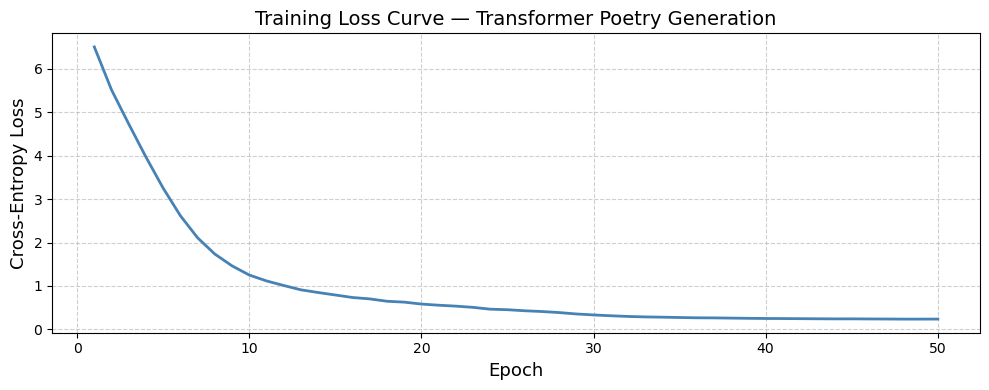

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Cross-Entropy Loss', fontsize=13)
plt.title('Training Loss Curve — Transformer Poetry Generation', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()


结果分析：曲线总体下降表示模型有效学习到了字符级条件分布，为模型收敛性提供了直观证据。

### 4.7 生成实验
使用Top-k+Temperature采样进行自回归生成。

生成策略：
- 起始词：`明月`。
- 采样温度 `temperature`：控制分布平滑程度。
- `top_k`：只在概率最高的前 k 个候选中采样。
- 屏蔽 `<PAD>/<BOS>/<UNK>`：避免无效符号进入输出。

In [9]:
@torch.no_grad()
def generate_poem(
    model,
    char2idx,
    idx2char,
    start_chars: str  = '明月',
    max_new_tokens: int = 35,
    temperature: float  = 0.9,
    top_k: int          = 15,
) -> str:
    
    model.eval()
    dev = next(model.parameters()).device

    tokens = [BOS_IDX] + [char2idx.get(c, UNK_IDX) for c in start_chars]
    generated = len(start_chars)

    while generated < max_new_tokens:
        src   = torch.tensor([tokens], dtype=torch.long, device=dev)  #(1,T)
        logits = model(src)                                           #(1,T,V)
        next_logits = logits[0, -1, :].clone()                        #(V,)

        for special in (PAD_IDX, BOS_IDX, UNK_IDX):
            next_logits[special] = float('-inf')
        next_logits = next_logits / temperature

        if top_k > 0:
            topk_vals, _ = torch.topk(next_logits, min(top_k, next_logits.size(-1)))
            threshold     = topk_vals[-1]
            next_logits   = next_logits.masked_fill(next_logits < threshold, float('-inf'))

        probs      = torch.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()

        if next_token == EOS_IDX:
            break

        tokens.append(next_token)
        generated += 1

    result = ''.join(
        idx2char[t] for t in tokens[1:]
        if t not in (PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX)
    )
    return result

print("=" * 40)
print("以「明月」为起始词生成七言绝句")
print("=" * 40)
for i in range(5):
    poem = generate_poem(model, char2idx, idx2char,
                         start_chars='明月', temperature=1.2, top_k=15)
    print(f"\n第 {i+1} 首：")
    print(poem)


以「明月」为起始词生成七言绝句

第 1 首：
明月透人宴溪斜，簾外青泠白髪生。不意尙遠塵歇去，時聽西山十髪人。

第 2 首：
明月落山散不同，天氣清明虎頭看。向君欲向海頭事，不見清凉十里秋。

第 3 首：
明月生魄迹未安，纔破五六漸盤桓。今夜吐艷如半璧，游人得向三更看。

第 4 首：
明月落山濛雞漲，不嫌高屋隔闊入。白頭定得何人計，山日相依舊潮頭。

第 5 首：
明月已報百吏散，坐石垂來没一毫。門掩白光何所悟，世間言又鑑中濃。


结果分析：
- 可观察到模型已能生成具有古诗语感的连续中文文本。
- 当 `temperature` 较高时，文本更发散；较低时更保守。
- 当 `top_k` 增大时多样性上升，但格式稳定性可能下降。

## 5、实验结论

- 本实验完成了从数据筛选、字符建模到 Transformer 训练与生成的完整流程。
- 因果掩码+自回归目标使模型能够进行逐字生成，符合语言模型机制。
- 训练损失曲线与生成样例共同表明模型具备基础古诗生成能力。

## 6、可改进方向

- 引入验证集与困惑度（Perplexity）评估，增强量化对比。
- 增加格式约束解码（如句长/标点控制）提升七言绝句规范性。